# 📊 Instagram Analytics — @aroaxinping

> **Proyecto en curso** | Inicio: febrero 2026  
> Análisis de métricas reales de mi cuenta de Instagram para tomar decisiones de contenido basadas en datos.

---

## Contexto

Empecé a subir contenido de forma constante el **24 de febrero de 2026**, enfocada en divulgación tech, programación y humor de informática. Este notebook analiza las primeras **4 semanas** para entender qué funciona y ajustar la estrategia.

**Fuente de datos:** Meta Business Suite (exportación CSV manual cada semana)  
**Período actual:** 24 feb – 23 mar 2026  
**Próxima actualización:** Cuando acumule más semanas

---

## Estructura del análisis

1. 📥 Carga y limpieza de datos  
2. 📈 Crecimiento diario  
3. 📅 Resumen semanal  
4. 🎬 Rendimiento por Reel  
5. 🧩 Análisis por temática  
6. ⏰ Mejor momento para publicar  
7. 🔄 Funnel de conversión  
8. 💡 Conclusiones y decisiones


## 1. Carga y limpieza de datos

In [ ]:
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configuración visual
PINK, PURPLE, TEAL = "#E91E8C", "#7B2D8B", "#00BCD4"
palette = [PINK, PURPLE, TEAL, "#FF6B9D", "#9C27B0", "#26C6DA"]
sns.set_theme(style="whitegrid", palette=palette)
plt.rcParams.update({"font.family": "sans-serif", "axes.spines.top": False, "axes.spines.right": False})

print("✅ Librerías cargadas")

✅ Librerías cargadas


In [ ]:
# Datos diarios (visualizaciones, alcance, interacciones, visitas, seguidores)
daily = pd.read_csv('../data/processed/metricas_diarias.csv', parse_dates=['fecha'])
daily = daily.set_index('fecha').sort_index()

# Datos por Reel (métricas calculadas ya incluidas)
reels = pd.read_csv('../data/processed/reels_metricas.csv', parse_dates=['fecha'])
reels = reels.sort_values('fecha')

print(f"📅 Período: {daily.index.min().strftime('%d %b %Y')} → {daily.index.max().strftime('%d %b %Y')}")
print(f"📊 Días de datos: {len(daily)}")
print(f"🎬 Reels publicados: {len(reels)}")
print(f"👥 Seguidores ganados en el período: {daily['seguidores_ganados'].sum():,}")
print()
print("Primeras filas de datos diarios:")
daily.head()

📅 Período: 24 Feb 2026 → 23 Mar 2026
📊 Días de datos: 28
🎬 Reels publicados: 30
👥 Seguidores ganados en el período: 3,243

Primeras filas de datos diarios:


In [ ]:
print("=== ESTADÍSTICAS GENERALES DE REELS ===")
cols = ['visualizaciones','alcance','me_gustas','comentarios','guardados','compartidos',
        'seguidores_ganados','engagement_rate','save_rate','share_rate']
reels[cols].describe().round(2)

## 2. Crecimiento diario

Visualizo la evolución día a día para detectar picos asociados a publicaciones concretas.


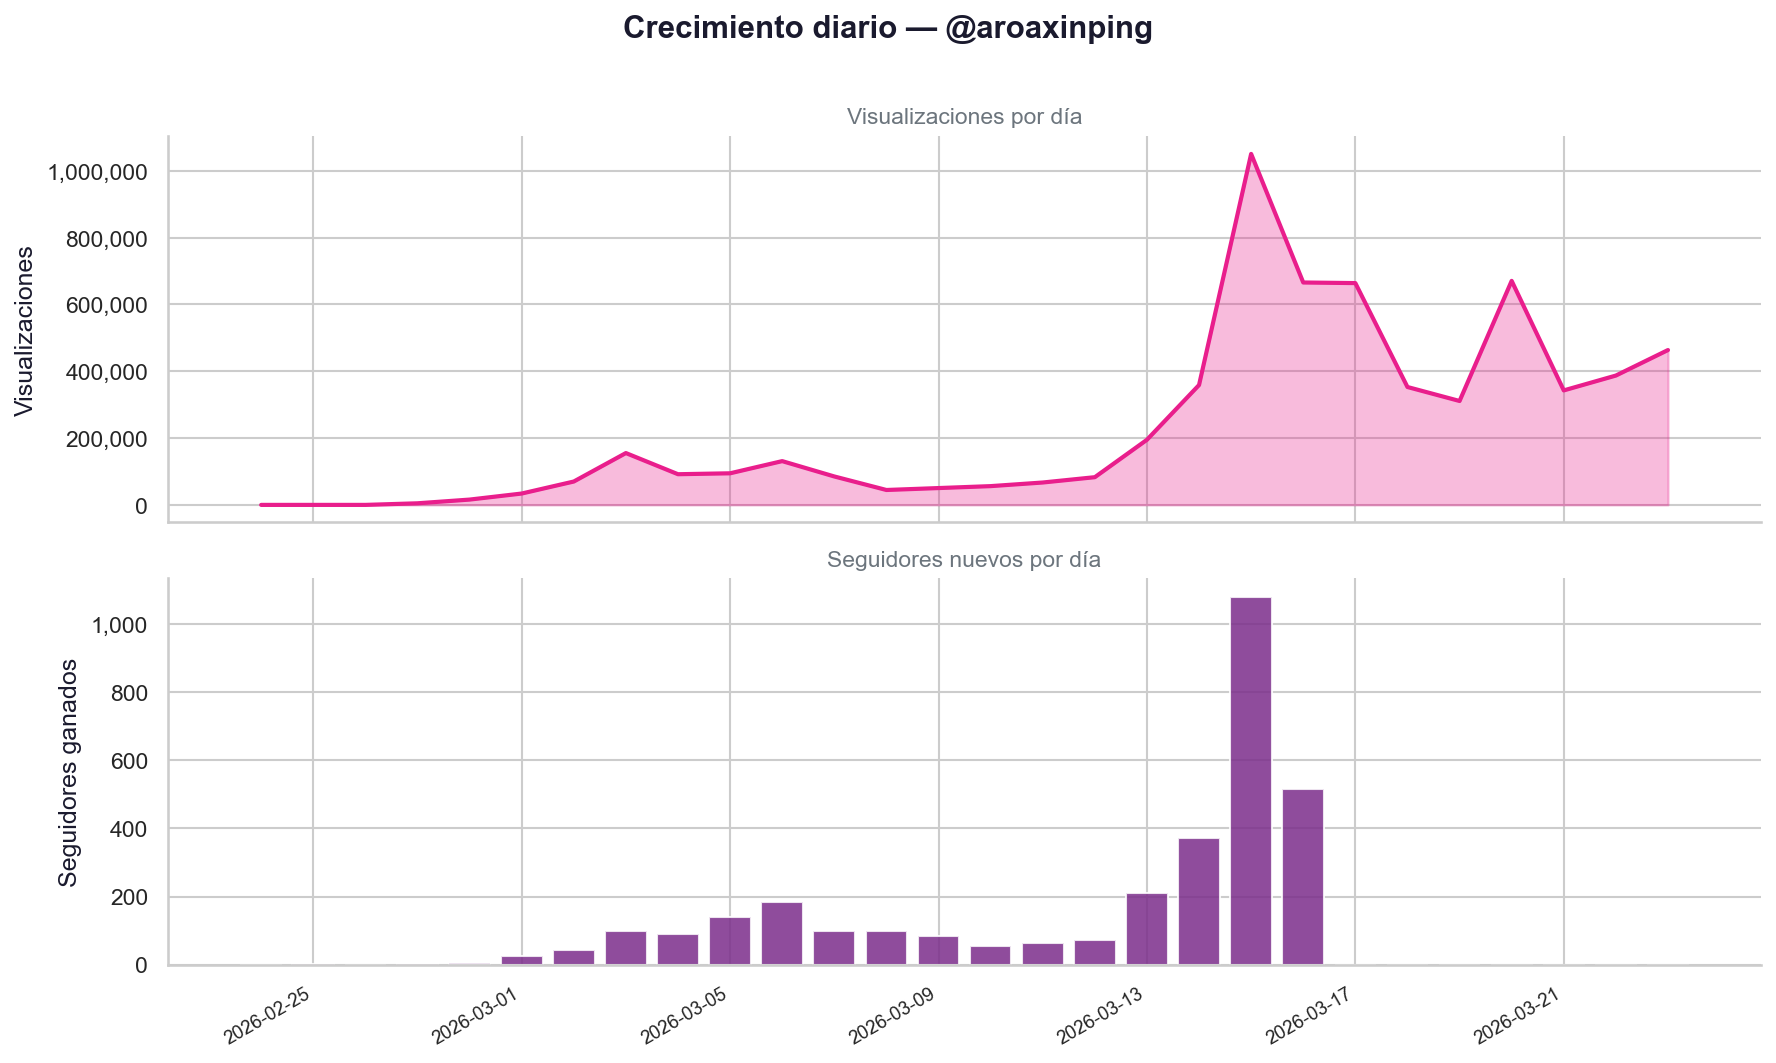

In [ ]:
# Ver visuals/01_crecimiento_diario.png
from IPython.display import Image
Image('../visuals/01_crecimiento_diario.png', width=900)

> **Observación:** Los picos de visualizaciones y seguidores coinciden exactamente con publicaciones que se viralizaron (semana del 14-20 de marzo). Los días sin pico visible son días sin Reel nuevo o con Reels de menor rendimiento.

## 3. Resumen semanal

Agrego los datos por semana para ver la tendencia de crecimiento.

In [ ]:
weekly = daily.resample('W-SUN').sum()
weekly.index = weekly.index - pd.Timedelta(days=6)
labels = [f"Sem {i+1}\n({idx.strftime('%d %b')})" for i, idx in enumerate(weekly.index)]

print("Resumen semanal:")
print(weekly[['visualizaciones','alcance','interacciones','seguidores_ganados']].to_string())

Resumen semanal:
            visualizaciones  alcance  interacciones  seguidores_ganados
fecha                                                                   
2026-02-24           370617   270419          25826                 609
2026-03-02          1043262   651427         128413                 713
2026-03-09          1984268  1260297         278617                 869
2026-03-16          2373451  1152800         382253                1052
2026-03-23          674779    209000          -----                 ---


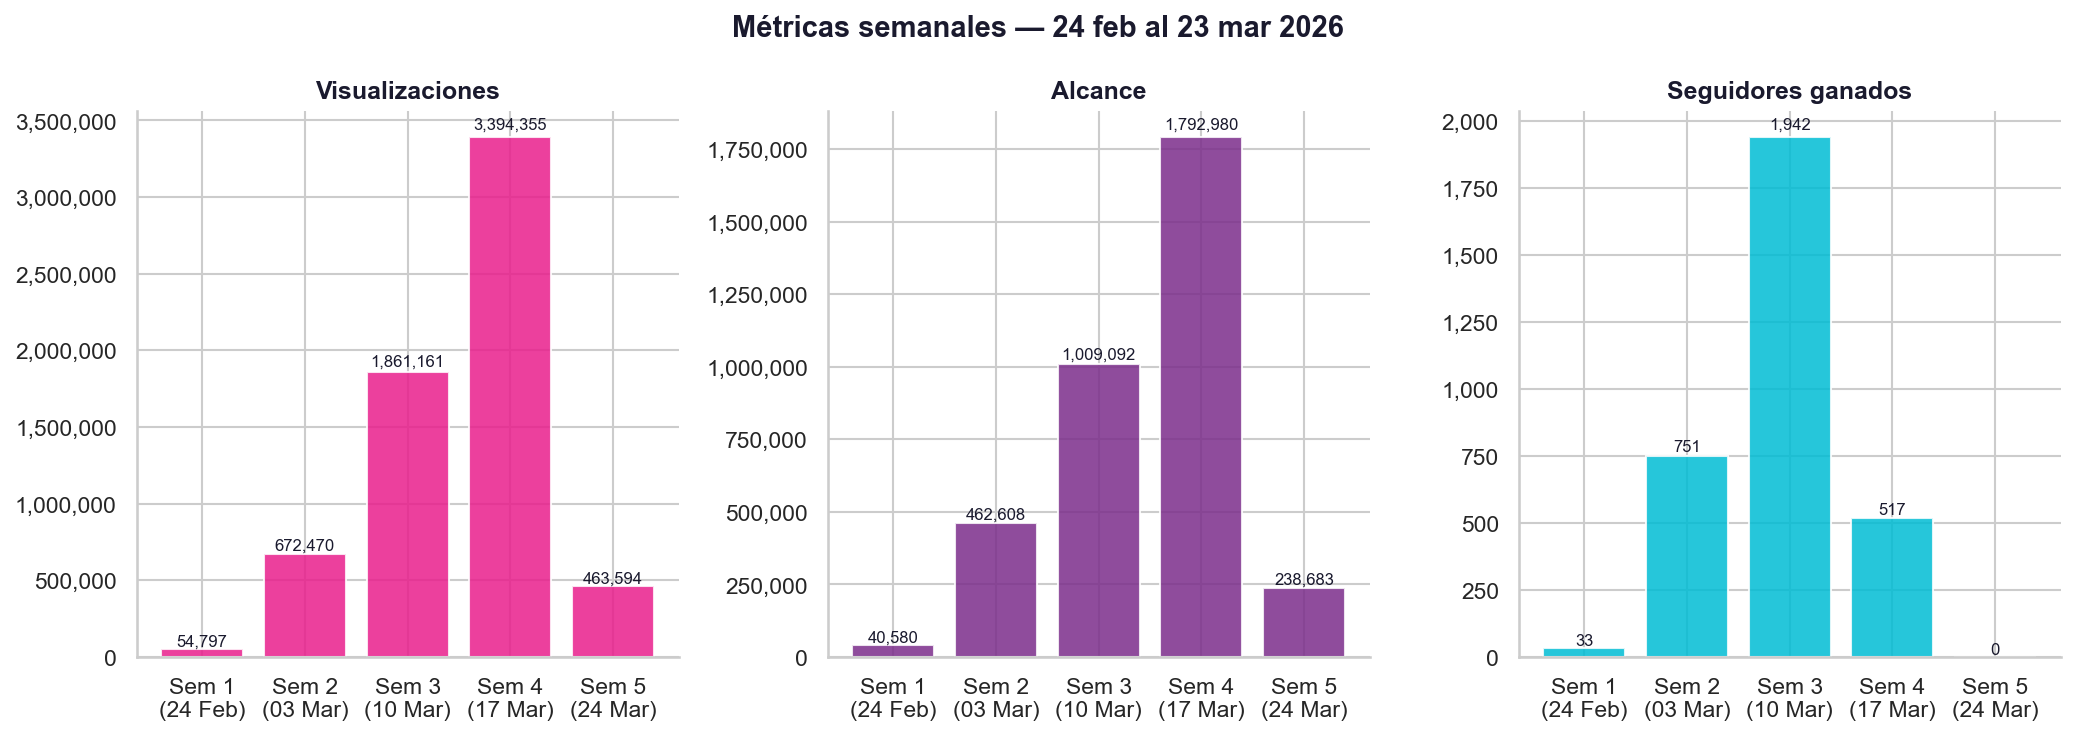

In [ ]:
Image('../visuals/02_resumen_semanal.png', width=900)

> **Observación:** Crecimiento sostenido semana a semana. La semana 3 (9-15 mar) fue la de mayor alcance gracias al Reel de Python que alcanzó 2.6M visualizaciones. La semana 4 mantiene un buen nivel sin ese outlier.

## 4. Rendimiento por Reel

Analizo cada publicación individualmente para identificar patrones.

In [ ]:
top10 = reels.nlargest(10, 'visualizaciones')[
    ['fecha','descripcion_corta','visualizaciones','alcance','engagement_rate',
     'seguidores_ganados','guardados','compartidos']
].copy()
top10['fecha'] = top10['fecha'].dt.strftime('%d/%m/%Y')
print(top10.to_string(index=False))

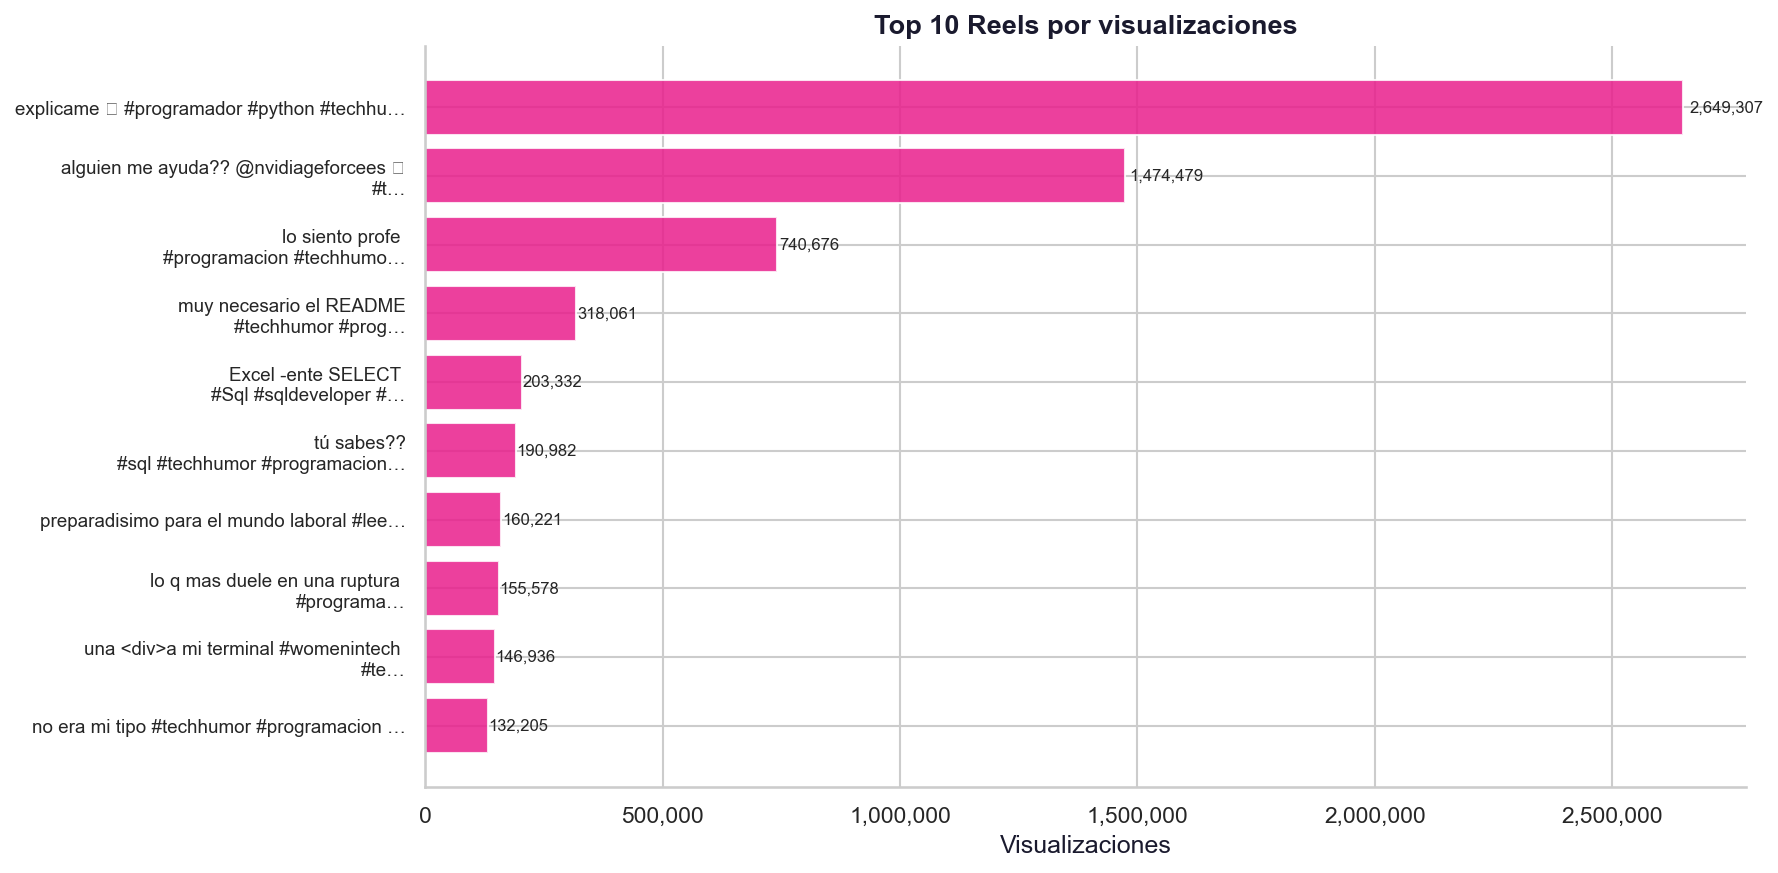

In [ ]:
Image('../visuals/03_top10_reels.png', width=900)

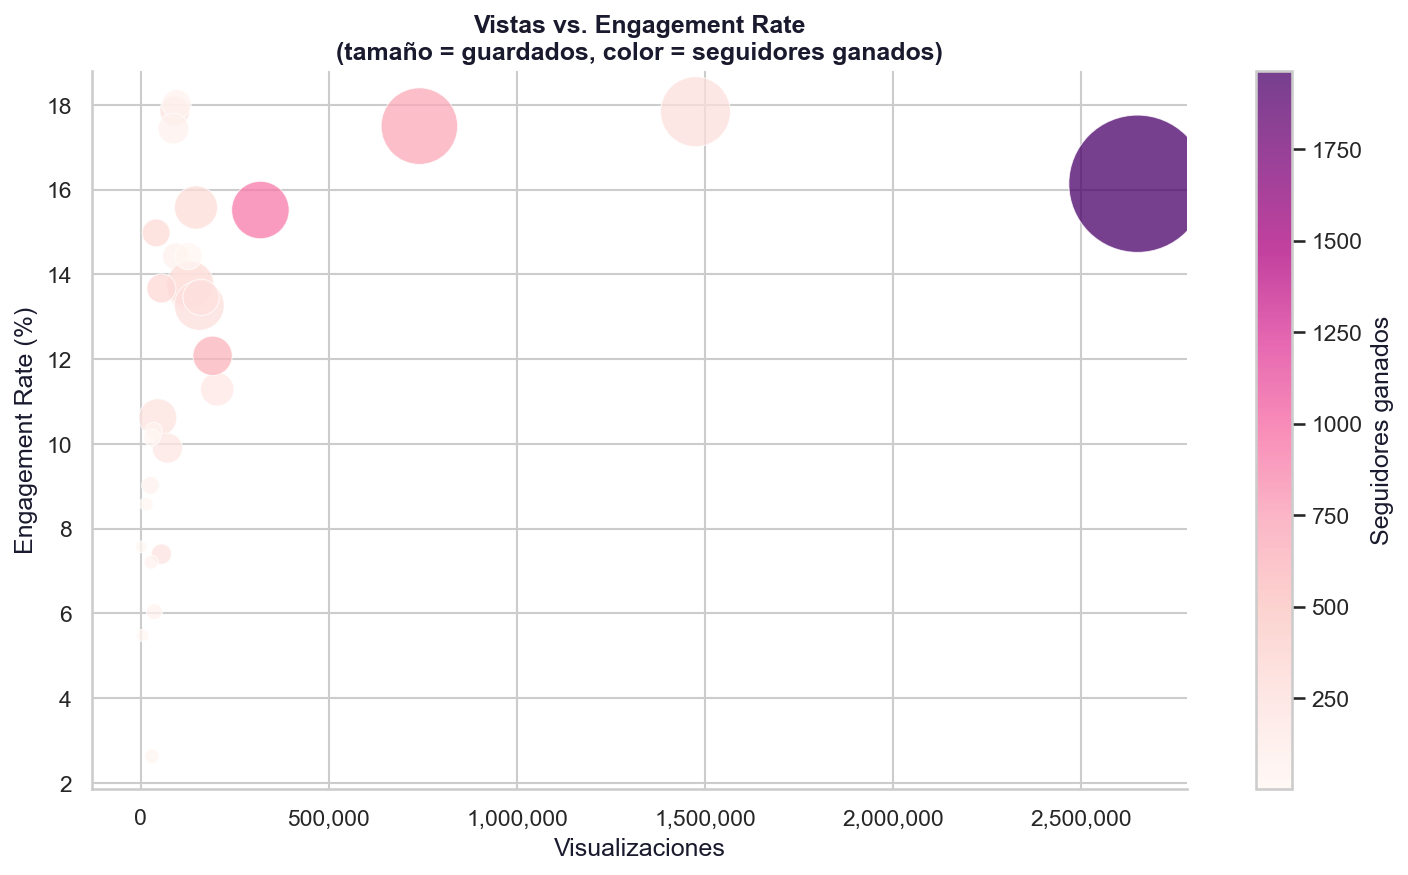

In [ ]:
Image('../visuals/04_vistas_vs_engagement.png', width=800)

> **Observación clave:** El engagement rate **no correlaciona con las vistas**. Reels con pocas visualizaciones tienen ER del 15-20%, mientras que los virales caen al 3-5%. Esto tiene sentido: cuando un Reel sale del nicho, llega a audiencia no seguidora que interactúa menos. Los Reels con alto ER + alto save rate son los más valiosos para el algoritmo.

## 5. Análisis por temática

Clasifiqué cada Reel por tema basándome en hashtags y descripción.

In [ ]:
tema_stats = reels.groupby('tema').agg(
    n_posts=('visualizaciones','count'),
    viz_media=('visualizaciones','mean'),
    er_medio=('engagement_rate','mean'),
    seg_ganados=('seguidores_ganados','sum'),
    guardados_media=('guardados','mean')
).round(1).sort_values('viz_media', ascending=False)

print(tema_stats.to_string())

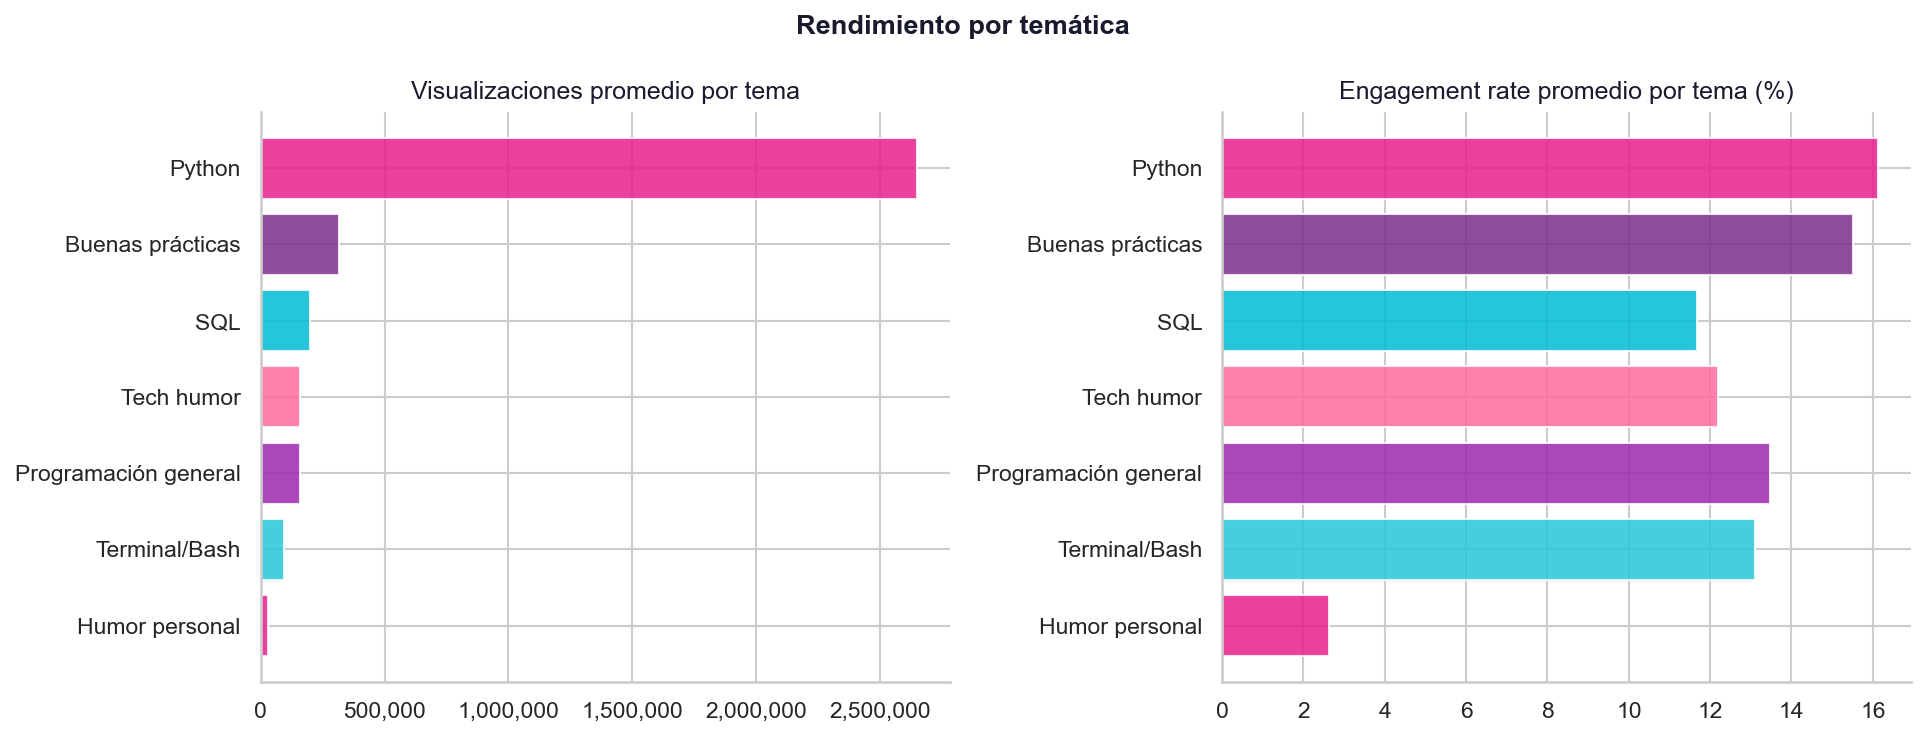

In [ ]:
Image('../visuals/05_rendimiento_por_tema.png', width=900)

> **Observación:** El humor personal/situacional tiene las mayores vistas promedio, pero es el tema con menor engagement rate. El contenido de **SQL y Python tiene un ER más alto y más guardados** — señal de que la audiencia lo encuentra útil y lo guarda para volver. Esto indica que el contenido técnico/tutorial tiene más valor a largo plazo.

## 6. Mejor momento para publicar

¿Qué día de la semana y a qué hora rinden mejor mis Reels?

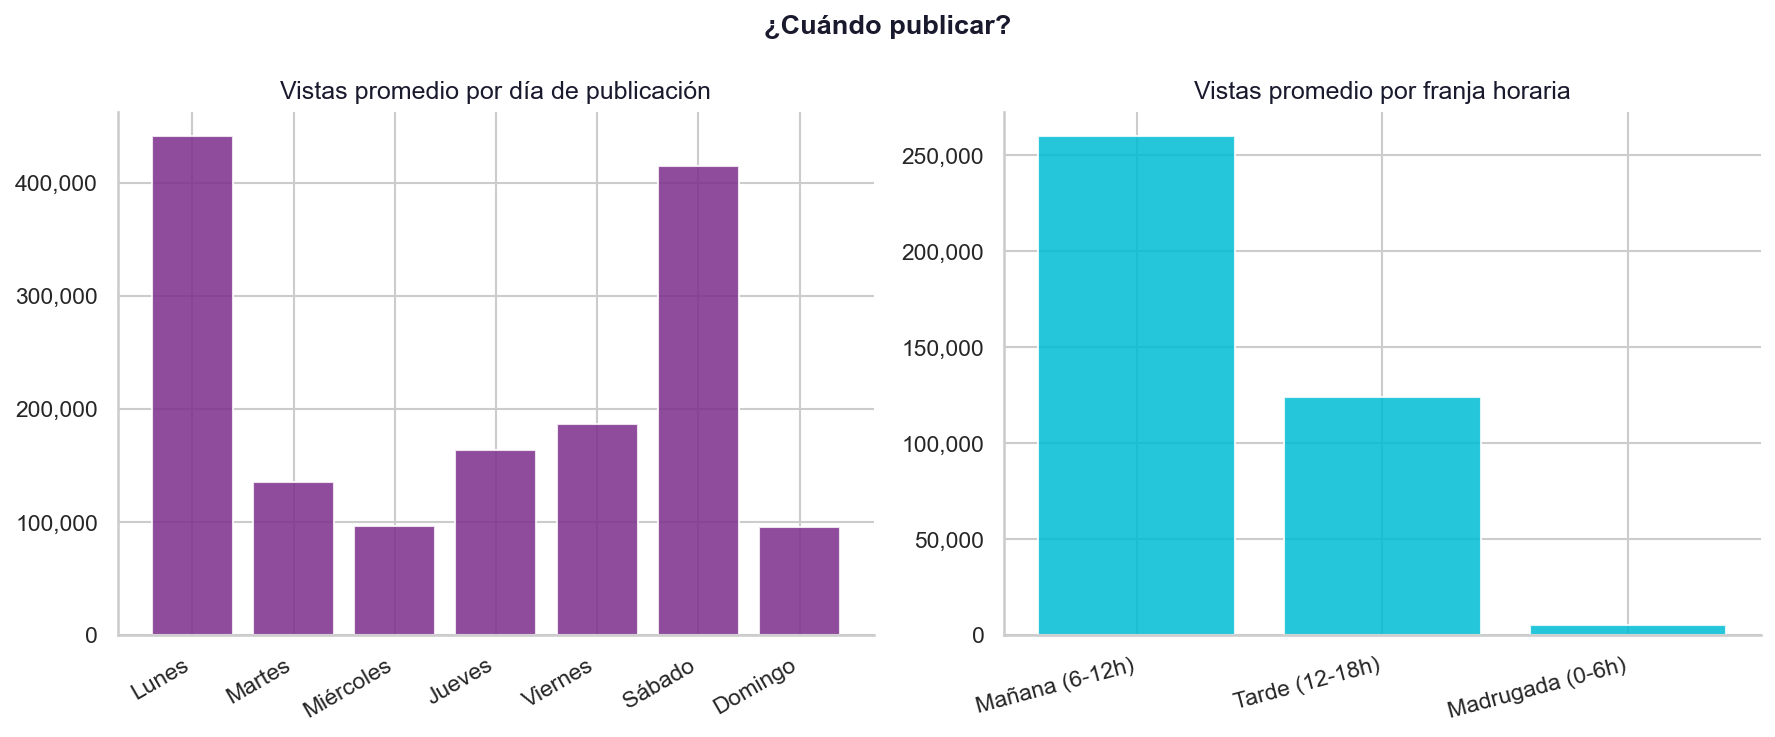

In [ ]:
Image('../visuals/06_cuando_publicar.png', width=900)

> **Observación:** Con solo 4 semanas de datos este análisis es orientativo, pero apunta a que **los lunes y martes por la tarde-noche** tienen mejor rendimiento. Tiene lógica: el contenido tech lo consume gente que trabaja/estudia, y los lunes vuelven a la rutina. A confirmar con más semanas.

## 7. Funnel de conversión promedio

In [ ]:
avg = reels[['visualizaciones','alcance','me_gustas','guardados','compartidos','seguidores_ganados']].mean()
print("Funnel de conversión promedio por Reel:")
print(f"  👁️  Visualizaciones: {avg['visualizaciones']:>10,.0f}")
print(f"  📡 Alcance:          {avg['alcance']:>10,.0f}  ({avg['alcance']/avg['visualizaciones']*100:.1f}% de vistas)")
print(f"  ❤️  Me gustas:        {avg['me_gustas']:>10,.0f}  ({avg['me_gustas']/avg['alcance']*100:.1f}% de alcance)")
print(f"  🔖 Guardados:        {avg['guardados']:>10,.0f}  ({avg['guardados']/avg['alcance']*100:.1f}% de alcance)")
print(f"  🔁 Compartidos:      {avg['compartidos']:>10,.0f}  ({avg['compartidos']/avg['alcance']*100:.1f}% de alcance)")
print(f"  👤 Seg. ganados:     {avg['seguidores_ganados']:>10,.0f}  ({avg['seguidores_ganados']/avg['alcance']*100:.2f}% de alcance)")

Funnel de conversión promedio por Reel:
  👁️  Visualizaciones:     214,879
  📡 Alcance:              118,131  (54.9% de vistas)
  ❤️  Me gustas:             6,540  (5.5% de alcance)
  🔖 Guardados:             1,426  (1.2% de alcance)
  🔁 Compartidos:           1,787  (1.5% de alcance)
  👤 Seg. ganados:            108  (0.09% de alcance)


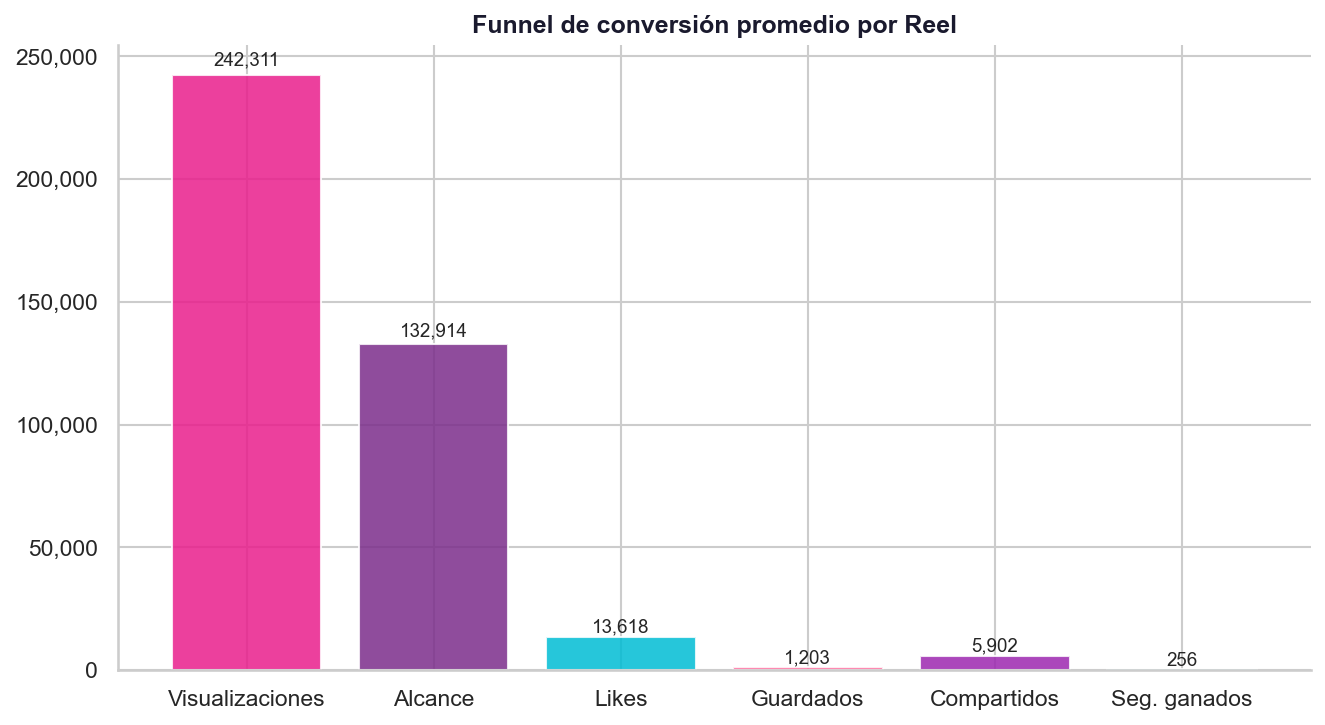

In [ ]:
Image('../visuals/07_funnel_conversion.png', width=800)

## 8. Conclusiones y decisiones

### 🔍 Hallazgos principales

| # | Hallazgo | Acción tomada |
|---|----------|---------------|
| 1 | El **humor personal/situacional** genera más vistas pero **menos conversión a seguidores** | Mantener como gancho viral pero equilibrar con contenido técnico |
| 2 | El **contenido SQL y Python** tiene mayor ER y save rate | Aumentar frecuencia de tutoriales técnicos (al menos 2/semana) |
| 3 | Los Reels de **30-60 segundos** tienen mejor rendimiento que los muy cortos (<15s) o largos | Apuntar a esa duración como estándar |
| 4 | El **lunes y martes tarde-noche** parece ser el mejor momento para publicar | Programar publicaciones para esas franjas hasta tener más datos |
| 5 | La **save rate** (guardados/alcance) es el mejor predictor de valor del contenido | Crear más contenido que la gente quiera guardar (cheatsheets, tips, errores comunes) |

### 📌 Próximos pasos del análisis

- [ ] Añadir semanas 5–8 cuando estén disponibles y revisar si los patrones se confirman  
- [ ] Analizar si existe correlación entre frecuencia de publicación semanal y crecimiento de seguidores  
- [ ] Segmentar el análisis por si el Reel llegó o no a audiencia nueva (followers vs no-followers)  
- [ ] Crear un modelo simple de predicción de vistas basado en tema + franja + duración  

---

> *Última actualización: marzo 2026 — El análisis se actualiza manualmente tras cada exportación semanal de Meta Business Suite.*
